# **Protein Secondary Structure Prediction using Graph Neural Network**

Proteins are chains of amino acids joined together by peptide bonds . Each amino acid in the chain is polar, i.e. it has separated positive and negative charged regions with a free carbonyl group, which can act as hydrogen bond acceptor and an NH group, which can act as hydrogen bond donor. These groups can therefore interact in the protein structure. The 20 amino acids can be classified according to the chemistry of the side chain which also plays an important structural role.

The protein structure can be considered as a sequence of secondary structure elements, such as α helices, β sheets and coils, which together constitute the overall three-dimensional configuration of the protein chain.

# **Import the Library**

In [1]:
import numpy as np                                     # linear algebra
import pandas as pd                                    # data processing, CSV file I/O (e.g. pd.read_csv)
import copy     
import torch#to copy list
from sklearn.model_selection import train_test_split   #to split dataset into train and test set
from sklearn.svm import SVC                            #to create svc instance
from sklearn.metrics import classification_report      #to create report for precision,recall,f1-score,accuracy
from sklearn import metrics                            #to get accuracy
from sklearn.model_selection import GridSearchCV
import torch
import torch.nn as nn
import torch.nn as nn
import torch_geometric.nn as pyg_nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv #to optimise the hyper-parameter
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report



In [2]:
torch.cuda.is_available()

False

# Directory of Dataset
find the directory of dataset

# Load the dataset

**PDB Dataset**<br>
Load the .csv file into dataframe and see if it is load properly .

In [3]:
df = pd.read_csv(r"H:\\THESIS\\DATASET\\2022-08-03-ss.cleaned.csv")
df.head()

,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa
0,1A30,C,EDL,CBC,CEC,3,False
1,1B05,B,KCK,CBC,CEC,3,False
2,1B0H,B,KAK,CBC,CEC,3,False
3,1B1H,B,KFK,CBC,CEC,3,False
4,1B2H,B,KAK,CBC,CEC,3,False


# **Data processing**

The PDB dataset is opened and processed using the python programming language. The 'seq' column has the primary sequence of protein and the 'sst8' has the seconday sequence of protein . The max length of any sequence set to 128 .
hasnonstdaa: whether the peptide contains nonstandard amino acids (B, O, U, X, or Z).
So those sequences are only taken which don't have nonstandard amino acids .

In [4]:
maxlen_seq = 128
input_seqs, target_seqs = df[['seq', 'sst8']][(df.len <= maxlen_seq) & (~df.has_nonstd_aa)].values.T
#input_grams = seq2ngrams(input_seqs)
print(input_seqs[0:5])

['EDL' 'KCK' 'KAK' 'KFK' 'KAK']


see the target sequence(secondary structure) and it's size .

In [5]:
print(target_seqs[0:5])
print(target_seqs.size)

['CBC' 'CBC' 'CBC' 'CBC' 'CBC']
103801


# **Looking for incomplete data**

Check the data whether there are differences in the number of characters of the primary structure and secondary structure (because the prediction of the secondary structure of the protein is included in the sequence labeling problem, it is certain that the number of characters of the primary structure and secondary structure is always the same)

In [6]:
for row in range(len(target_seqs)):
    secondary_lenth = len(target_seqs[row])
    primary_lenth = len(input_seqs[row])

    if(secondary_lenth != primary_lenth):
        print("(",row,") Secondary_Structure ->", target_seqs[row]," Primary_Structure -> ",input_seqs[row])

Find the total sequence of primary structure and secondary structure to find out if there is no anomaly .

In [7]:
secondary_count = 0
primary_count = 0
for row in range(len(target_seqs)):
    secondary_lenth = len(target_seqs[row])
    primary_lenth = len(input_seqs[row])
    secondary_count = secondary_count + secondary_lenth
    primary_count = primary_count + primary_lenth
    if(secondary_lenth != primary_lenth):
        print("(",row,") Secondary_Structure ->", target_seqs[row]," Primary_Structure -> ",input_seqs[row])

print("count of secondary structure : ",secondary_count)
print("count of primary structure : ",primary_count)

count of secondary structure :  8386644
count of primary structure :  8386644


# **Orthogonal Encoding - Target Labeling**

Every primary and secondary structure data is split so that it can be encoded into orthogonal form

**Split function**<br>
split the string sequence into character array .<br>
input -> string <br>
output -> array of character

In [8]:
def split(sequence):
    return [char for char in sequence]

input_seqs is 2D array which has string in each row. Make it character array in each row .<br>
primary structure from input_seqs go to primary_split .<br>
secondary structure from target_seqs go to secondary_split .

In [9]:
primary_split = []
secondary_split = []
for row in range(int(len(target_seqs)/40)):
    primary_split.append(split(input_seqs[row]))
    secondary_split.append(split(target_seqs[row]))


The results of the split primary and secondary structure of the protein are then converted into orthogonal encoding and target labeling. A switch case snippet for each amino acid in the primary structure of a protein as follows .<br>
Secondary structure character represent ->
1. H= α-helix
2. C= Loops and irregular elements
3. E= β-strand
4. B= β-bridge
5. G= 3-helix
6. I= π-helix
7. T= Turn
8. S= Bend

In [10]:
def orthogonal_primary(arg):
    switch = {
        'A' : np.array([1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),  # 20 amino acids
        'C' : np.array([0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'E' : np.array([0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'D' : np.array([0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'G' : np.array([0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'F' : np.array([0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'I' : np.array([0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0]),
        'H' : np.array([0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0]),
        'K' : np.array([0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0]),
        'M' : np.array([0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0]),
        'L' : np.array([0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0]),
        'N' : np.array([0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0]),
        'Q' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0]),
        'P' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0]),
        'S' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0]),
        'R' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0]),
        'T' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0]),
        'W' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0]),
        'V' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0]),
        'Y' : np.array([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1])
    }

    return switch.get(arg)

def orthogonal_secondary(arg):
    switch = {
        'H' : 0,                    # H= α-helix
        'C' : 1,                    # C= Loops and irregular elements
        'E' : 2,                    # E= β-strand
        'B' : 3,                    # B= β-bridge
        'G' : 4,                    # G= 3-helix
        'I' : 5,                    # I= π-helix
        'T' : 6,                    # T= Turn
        'S' : 7                     # S= Bend
    }

    return switch.get(arg)

For each character of primary structure and secondary structure use onehot key in the 20 amino acid .<br>
In secondary structure encode the 8 classification using 0-7 integer .

In [11]:
for row in range(len(primary_split)):
    sequence = primary_split[row]
    for col in range(len(sequence)):
        # print(sequence[col])
        sequence[col] = orthogonal_primary(sequence[col])
        #print(sequence[col])

In [12]:
for row in range(len(secondary_split)):
    sequenceS = secondary_split[row]
    for col in range(len(sequenceS)):
        sequenceS[col] = orthogonal_secondary(sequenceS[col])

In [13]:
primary_split[0:5]

[[array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])],
 [array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])],
 [array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])],
 [array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])],
 [array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  

In [14]:
secondary_split[0:5]

[[1, 3, 1], [1, 3, 1], [1, 3, 1], [1, 3, 1], [1, 3, 1]]

# Make the Graph

**graph_sum2**<br>
this function take input 2 node (amino acid character's onehot key) and return the sum of 2 node .<br>
**graph_sum3**<br>
this function take input 3 node (amino acid character's onehot key) and return the sum of 3 node .

In [15]:
def graph_sum2(seq1,seq2):
    result = [None]*len(seq1)
    for col in range(len(seq1)):
        result[col] =  seq1[col]+seq2[col]
    return result


def graph_sum3(seq1,seq2,seq3):
    result = [None]*len(seq1)
    for col in range(len(seq1)):
        result[col] =  seq1[col]+seq2[col]+seq3[col]
    return result

**Graph of primary structure**<br>
The primary structure is a linear string of character/amino acid(node) .<br>
Example : ***ABBA***<br>
In Graph Neural Network , we take each node and sum the information value of it's adjacent node. As a result we find a new value for each node which is dependable for it's adjacent nodes .<br>

the border node will use graph_sum2 function as it has only 1 adjacent node and the rest will use graph_sum3 function .

In [16]:
graph_input = copy.deepcopy(primary_split)
for row in range(len(primary_split)):
    sequence = primary_split[row]
    graph_input[row][0]=graph_sum2(sequence[0],sequence[1])
    graph_input[row][len(sequence)-1]=graph_sum2(sequence[len(sequence)-1],sequence[len(sequence)-2])
    for col in range(1,len(sequence)-1):
        graph_input[row][col] = graph_sum3(sequence[col-1],sequence[col],sequence[col+1])

graph_input[0:5]

[[[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
 [[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
 [[1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
 [[0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
 [[1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]]

Make the secondary structure in a array of data using targetY function .

In [17]:
def targetY(data_list):
    Y = []
    for i in range(len(data_list)):
        for j  in range(len(data_list[i])):
            Y.append(data_list[i][j])
    return Y

In [18]:
y_label = targetY(secondary_split)

In [19]:
print(len(y_label))
print(y_label[0:5])

18642
[1, 3, 1, 1, 3]


The data feature is formed using the window_padding_data function. This function will accept the size of the sliding window and sequence of the primary structure of the protein. In this function features will be processed such as adding padding 0 at the beginning and end and taking the features of the results of windowing so that the output data can be directly trained on the SVM model

In [20]:
def window_padding_data(size, sequence):
    num = int(size/2)
    #print("initial :",sequence[0])
    #print("")
    zeros = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    for i in range(len(sequence)):
        for j in range(num):
            sequence[i].append(zeros)
            sequence[i].insert(0, zeros)
            #print(sequence[i])
            #print("")

    X = []
    temp = []

    for k in range(len(sequence)):
        #print(sequence[k])
        for l in range(len(sequence[k])-(size-1)):
            temp = sequence[k][l:l+size]
           # print(temp)
            X.append(temp)
            temp = []

    return X

In [21]:
X = window_padding_data(11,graph_input)
len(X)
X[0:5]

[[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])],
 [array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([0, 0, 0, 0, 0, 0,

Before being entered into the Scikit-Learn SVM model, the data is reshape to follow the input size of the model. The data is reshaped to the length of X(primary structure) times multiplied by 600 (x window size and 20 orthogonal encoding sizes.)

In [22]:
np.set_printoptions(threshold=np.inf)
X = np.array(X)
y_label = np.array(y_label)
X = X.reshape(len(X),11*20)
print(X[0:5])

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1
  0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
  0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 

Data is split into training and testing data. Next will be calculated with SVM and see the Classification Report

In [23]:
#split the dataset into train set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y_label, test_size = 0.20,random_state=54)

# Optimise the Hyper parameter

In [24]:
# # defining parameter range
# param_grid = {'C': [0.1, 1, 10, 100, 1000],
#              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
#              'kernel': ['rbf']}

# grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3)

# # fitting the model for grid search
# grid.fit(X_train, y_train)

In [25]:
# print best parameter after tuning
#print(grid.best_params_)
#
# print how our model looks after hyper-parameter tuning
#print(grid.best_estimator_)

In [26]:
#grid_predictions = grid.predict(X_test)
#
# Define different kernel functions
#kernel_functions = ['linear', 'poly', 'rbf', 'sigmoid']
# print classification report
#print(classification_report(y_test, grid_predictions))

In [27]:


'''# Defining parameter range
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'kernel': ['rbf']
}

# Initializing GridSearchCV
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)

# Fitting the model for grid search
grid.fit(X_train, y_train)

# Print the best parameters after tuning
print("Best parameters found: ", grid.best_params_)

# Making predictions
grid_predictions = grid.predict(X_test)

# Print classification report
print(classification_report(y_test, grid_predictions))

# Print the best estimator
print("Best estimator: ", grid.best_estimator_)'''


'# Defining parameter range\nparam_grid = {\n    \'C\': [0.1, 1, 10, 100, 1000],\n    \'gamma\': [1, 0.1, 0.01, 0.001, 0.0001],\n    \'kernel\': [\'rbf\']\n}\n\n# Initializing GridSearchCV\ngrid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)\n\n# Fitting the model for grid search\ngrid.fit(X_train, y_train)\n\n# Print the best parameters after tuning\nprint("Best parameters found: ", grid.best_params_)\n\n# Making predictions\ngrid_predictions = grid.predict(X_test)\n\n# Print classification report\nprint(classification_report(y_test, grid_predictions))\n\n# Print the best estimator\nprint("Best estimator: ", grid.best_estimator_)'

# Use the SVM to find the classification

In [28]:
#for i in range(1,101):
#    X_train, X_test, y_train, y_test = train_test_split(X, y_label, test_size = 0.20,random_state=i)
svc = SVC(kernel='rbf', gamma = 0.1, C=10)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)
y_true = y_test
#    print("i = ",i,"acc = ",metrics.accuracy_score(y_test, y_pred))
print("Accuracy = ",metrics.accuracy_score(y_test, y_pred)*100)
print(classification_report(y_true,y_pred))

Accuracy =  87.28881737731295
              precision    recall  f1-score   support

           0       0.95      0.70      0.81        60
           1       0.89      0.96      0.92      2597
           2       0.88      0.77      0.82       390
           3       0.83      0.68      0.75       155
           4       0.61      0.46      0.53        41
           6       0.73      0.53      0.61       174
           7       0.80      0.61      0.69       312

    accuracy                           0.87      3729
   macro avg       0.82      0.67      0.73      3729
weighted avg       0.87      0.87      0.87      3729



In [29]:
EPSILON = 1e-10
print('Mean Absolute Error(MAE):', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error(MSE):', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error(RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('Relative Absolute Error(RAE):', np.sum(np.abs(y_test - y_pred)) / (np.sum(np.abs(y_test - np.mean(y_test))) + EPSILON))
print('Root Relative Squared Error(RRSE):', np.sqrt(np.sum(np.square(y_test - y_pred)) / np.sum(np.square(y_test - np.mean(y_test)))))

Mean Absolute Error(MAE): 0.43228747653526417
Mean Squared Error(MSE): 2.0525610083132206
Root Mean Squared Error(RMSE): 1.4326761700793451
Relative Absolute Error(RAE): 0.31516448601560226
Root Relative Squared Error(RRSE): 0.7467300345766923


# **Cross validation**

In [30]:

def evaluate_model(cv):
    scores = cross_val_score(svc, X, y_label, scoring='accuracy', cv=cv, n_jobs=-1)
    return np.mean(scores), scores.min(), scores.max()


In [31]:

'''from sklearn.model_selection import cross_val_score
folds = range(2,31)
means, mins, maxs = list(),list(),list()
from sklearn.model_selection import KFold
for k in folds:
    cv = KFold(n_splits=k, shuffle=True, random_state=1)
    k_mean, k_min, k_max = evaluate_model(cv)
    print('> folds=%d, accuracy=%.3f (%.3f,%.3f)' % (k, k_mean, k_min, k_max))
    means.append(k_mean)
    mins.append(k_mean - k_min)
    maxs.append(k_max - k_mean)'''


"from sklearn.model_selection import cross_val_score\nfolds = range(2,31)\nmeans, mins, maxs = list(),list(),list()\nfrom sklearn.model_selection import KFold\nfor k in folds:\n    cv = KFold(n_splits=k, shuffle=True, random_state=1)\n    k_mean, k_min, k_max = evaluate_model(cv)\n    print('> folds=%d, accuracy=%.3f (%.3f,%.3f)' % (k, k_mean, k_min, k_max))\n    means.append(k_mean)\n    mins.append(k_mean - k_min)\n    maxs.append(k_max - k_mean)"

In [32]:

from matplotlib import pyplot
pyplot.errorbar(folds, means, yerr=[mins, maxs], fmt='o')
#plot the ideal case in a separate color
pyplot.plot(folds, [ideal for _ in range(len(folds))], color='r')
# show the plot
pyplot.show()


NameError: name 'folds' is not defined

**Input and Output**
GNN

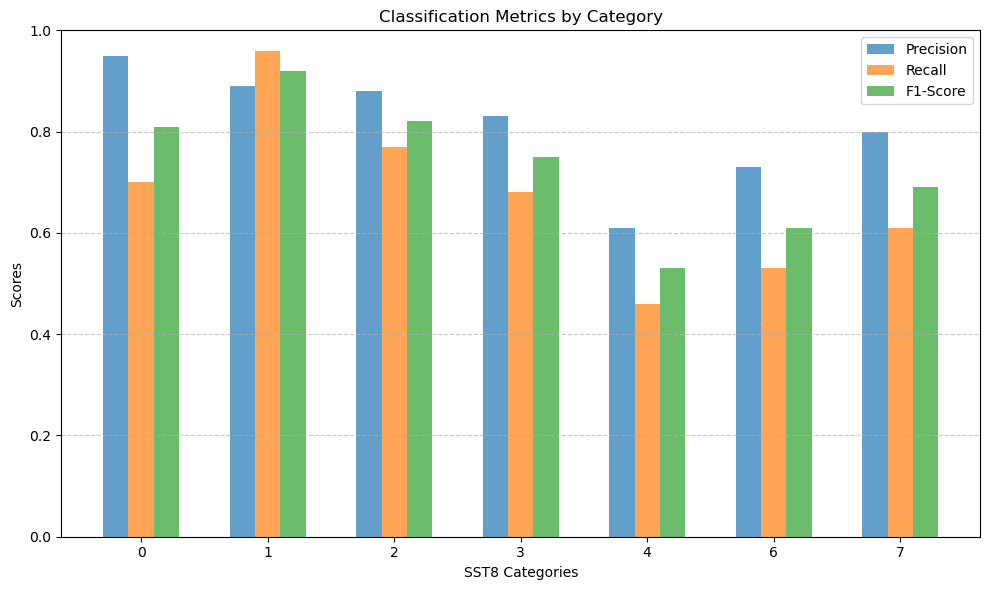

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ['0', '1', '2', '3', '4', '6', '7']
precision = [0.95, 0.89, 0.88, 0.83, 0.61, 0.73, 0.80]
recall = [0.70, 0.96, 0.77, 0.68, 0.46, 0.53, 0.61]
f1_score = [0.81, 0.92, 0.82, 0.75, 0.53, 0.61, 0.69]

# Bar width
bar_width = 0.2

# Bar positions
x = np.arange(len(categories))

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, precision, width=bar_width, label='Precision', alpha=0.7)
plt.bar(x, recall, width=bar_width, label='Recall', alpha=0.7)
plt.bar(x + bar_width, f1_score, width=bar_width, label='F1-Score', alpha=0.7)

# Labels and title
plt.xlabel('SST8 Categories')
plt.ylabel('Scores')
plt.title('Classification Metrics by Category')
plt.xticks(x, categories)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.tight_layout()
plt.show()


libs


In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [36]:
k = KNeighborsClassifier(algorithm='brute', n_neighbors= 3, weights= 'distance')
k.fit(X_train, y_train)
y_pred = k.predict(X_test)
y_true = y_test
#    print("i = ",i,"acc = ",metrics.accuracy_score(y_test, y_pred))
print("KNN Accuracy = ",metrics.accuracy_score(y_test, y_pred)*100)
print(classification_report(y_true,y_pred))

KNN Accuracy =  86.67203003486189
              precision    recall  f1-score   support

           0       0.92      0.75      0.83        60
           1       0.90      0.95      0.92      2597
           2       0.86      0.80      0.83       390
           3       0.71      0.69      0.70       155
           4       0.63      0.54      0.58        41
           6       0.68      0.60      0.64       174
           7       0.76      0.60      0.67       312

    accuracy                           0.87      3729
   macro avg       0.78      0.70      0.74      3729
weighted avg       0.86      0.87      0.86      3729



In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
from imblearn.over_sampling import SMOTE

In [39]:
smote = SMOTE(random_state=54)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [40]:
# Get confidence scores
y_pred_proba = k.predict_proba(X_test)  # Probabilities for each class
y_pred = k.predict(X_test)  # Hard predictions

# Compute classification matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Example: Extract confidence scores for predictions
confidence_scores = y_pred_proba.max(axis=1)  # Max probability for each prediction
print("Confidence Scores:", confidence_scores[:100])  # Display first 10 scores
cs = 0
for i in range(len(confidence_scores)):
    cs = cs + confidence_scores[i]
print("Average Confidence Score: ",cs/len(confidence_scores))

Confidence Scores: [1.         1.         0.66666667 1.         1.         1.
 1.         1.         0.5        1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.68989795 1.         0.67379864 0.67762176
 1.         1.         0.66666667 1.         1.         1.
 1.         1.         1.         1.         0.66666667 0.66666667
 1.         1.         1.         1.         1.         1.
 0.6339746  0.34066741 1.         1.         1.         1.
 1.         1.         1.         0.71934641 0.34178451 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         0.35843207 1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.       

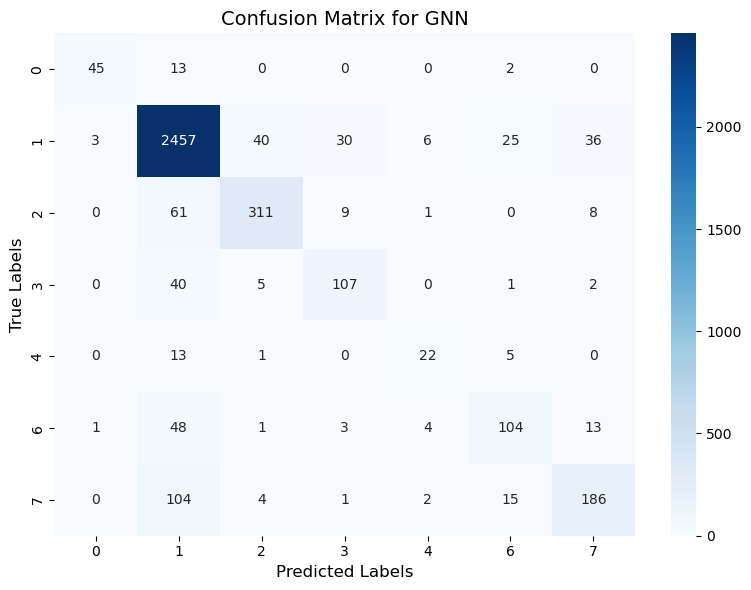

In [41]:
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0','1','2','3','4','6','7'],
            yticklabels=['0','1','2','3','4','6','7'])

plt.title("Confusion Matrix for GNN", fontsize=14)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels", fontsize=12)
plt.tight_layout()
plt.show()

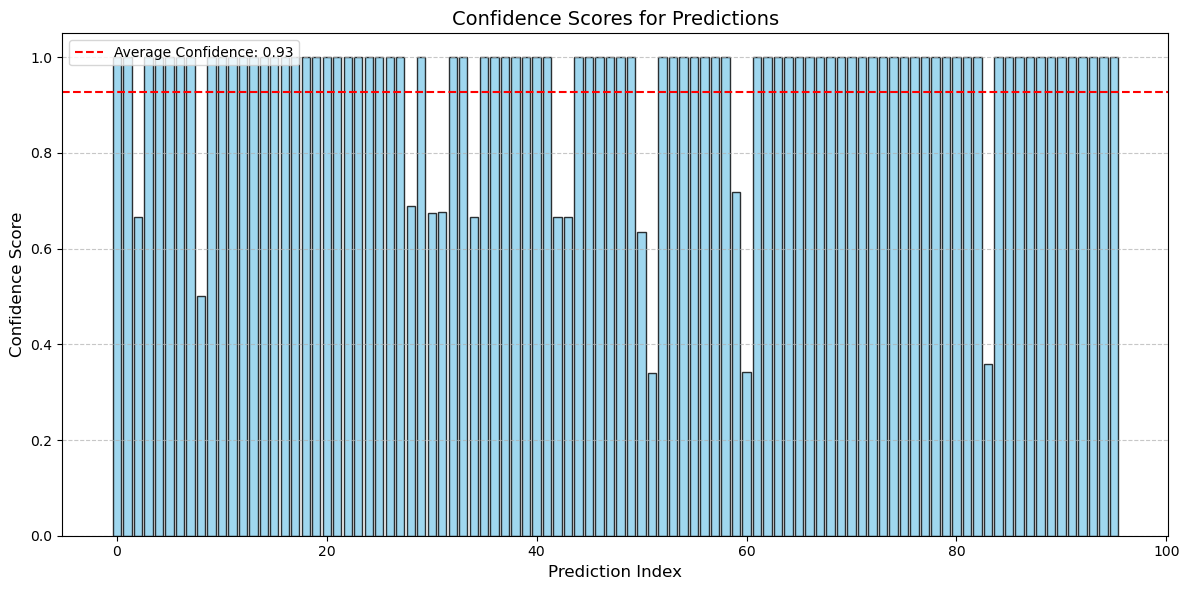

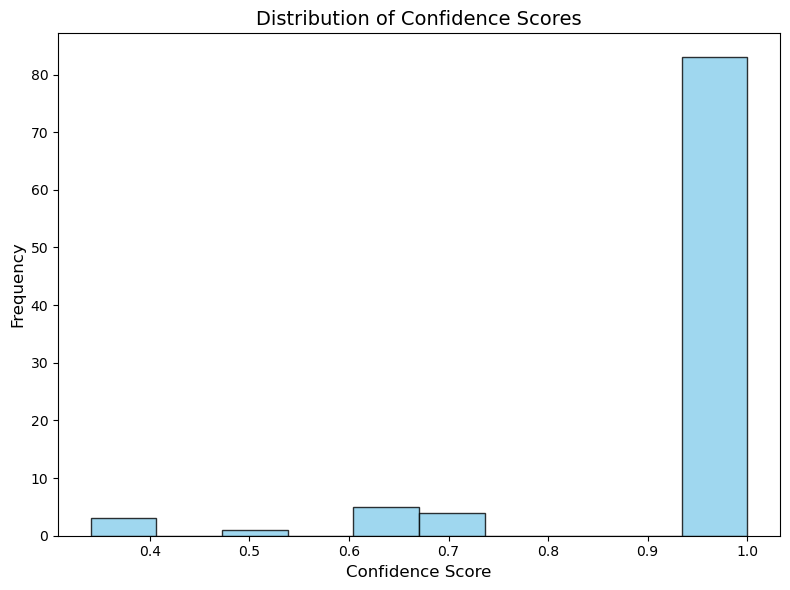

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Confidence scores data
confidence_scores = [
    1., 1., 0.66666667, 1., 1., 1., 1., 1., 0.5, 1., 1., 1.,
    1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
    1., 1., 0.68989795, 1., 0.67379864, 0.67762176, 1., 1., 0.66666667,
    1., 1., 1., 1., 1., 1., 1., 0.66666667, 0.66666667, 1., 1., 1.,
    1., 1., 1., 0.6339746, 0.34066741, 1., 1., 1., 1., 1., 1., 1.,
    0.71934641, 0.34178451, 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
    1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.35843207, 1.,
    1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.
]

# Average confidence score
average_confidence = 0.9276700803003282

# Bar chart for confidence scores
plt.figure(figsize=(12, 6))
plt.bar(range(len(confidence_scores)), confidence_scores, color='skyblue', edgecolor='black', alpha=0.8)

# Plot average confidence as a horizontal line
plt.axhline(y=average_confidence, color='red', linestyle='--', label=f'Average Confidence: {average_confidence:.2f}')

# Add labels and title
plt.xlabel('Prediction Index', fontsize=12)
plt.ylabel('Confidence Score', fontsize=12)
plt.title('Confidence Scores for Predictions', fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# Histogram for confidence score distribution
plt.figure(figsize=(8, 6))
plt.hist(confidence_scores, bins=10, color='skyblue', edgecolor='black', alpha=0.8)

# Add labels and title
plt.xlabel('Confidence Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Confidence Scores', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()